# Churn EDA — Internet Service Provider

Working through the data before modeling. Main things to figure out: what's actually in here, where the missing values come from, and which features are worth caring about.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## Data

In [2]:
df = pd.read_csv("../data/raw/internet_service_churn.csv")

Already see `reamining_contract` (typo in source data) has NaN in rows 1, 3, 4 — and all three of those customers churned. Worth keeping in mind.

In [3]:
df.head()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


`reamining_contract` is missing for ~30% of rows (50702 non-null out of 72274). `download_avg` and `upload_avg` missing for ~380 rows each, negligible.

The contract missingness almost certainly means no contract — month-to-month customers. 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   reamining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


In [5]:
df.tail()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
72269,1689648,1,1,0.09,0,1.25,0,0.0,0.0,0,1
72270,1689676,1,0,0.06,1,1.63,0,0.8,0.0,0,1
72271,1689679,1,0,0.02,0,2.19,0,1.5,0.2,0,1
72272,1689733,0,0,0.01,0,0.72,0,0.0,0.0,0,1
72273,1689744,1,1,0.01,0,0.82,0,0.0,0.0,0,1


In [6]:
df = df.rename(columns={'reamining_contract': 'remaining_contract'})

We create this flag before fillna - once we fill NaNs with 0, we permanently lose the information about who had no contract at all. This flag preserves it.

In [7]:
df['has_contract'] = df['remaining_contract'].notna().astype(int)

Filling NaN in `remaining_contract`

In [8]:
df['remaining_contract'] = df['remaining_contract'].fillna(0)

Group imputation by bill range — customers with similar bills tend to have similar usage patterns. Fallback to global median for any groups that are entirely empty.

In [9]:
df['download_avg'] = df['download_avg'].fillna(
    df.groupby(pd.cut(df['bill_avg'], bins=10))['download_avg'].transform('mean')
)
df['upload_avg'] = df['upload_avg'].fillna(
    df.groupby(pd.cut(df['bill_avg'], bins=10))['upload_avg'].transform('mean')
)

df['download_avg'] = df['download_avg'].fillna(df['download_avg'].median())
df['upload_avg'] = df['upload_avg'].fillna(df['upload_avg'].median())

Checking for NaN

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   remaining_contract           72274 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 72274 non-null  float64
 8   upload_avg                   72274 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
 11  has_contract                 72274 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 6.6 MB


In [11]:
print(df[['bill_avg', 'download_avg', 'upload_avg', 'subscription_age', 'download_over_limit', 'service_failure_count']].describe().round(2))

       bill_avg  download_avg  upload_avg  subscription_age  \
count  72274.00      72274.00    72274.00          72274.00   
mean      18.94         43.68        4.19              2.45   
std       13.22         63.24        9.79              2.03   
min        0.00          0.00        0.00             -0.02   
25%       13.00          6.80        0.50              0.93   
50%       19.00         28.10        2.10              1.98   
75%       22.00         60.20        4.80              3.30   
max      406.00       4415.20      453.30             12.80   

       download_over_limit  service_failure_count  
count             72274.00               72274.00  
mean                  0.21                   0.27  
std                   1.00                   0.82  
min                   0.00                   0.00  
25%                   0.00                   0.00  
50%                   0.00                   0.00  
75%                   0.00                   0.00  
max             

Capping at 99th percentile instead of dropping rows — we keep all the data, just prevent extreme values from dominating the model. 

In [12]:
df['subscription_age'] = df['subscription_age'].clip(lower=0)

for col in ['bill_avg', 'download_avg', 'upload_avg']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

id is just a row identifier — any correlation it shows with churn is meaningless leakage, not a real pattern.

In [13]:
df = df.drop(columns=['id'])

Remaining_contract at -0.79 — strongest signal by far, as expected. Customers with time left on their contract don't leave.
download_avg and upload_avg both strong negative — heavy users are satisfied users.
has_contract at -0.47 — our flag works, confirms that having no contract at all is a strong churn signal independent of how much time is left.
is_tv_subscriber and is_movie_package_subscriber — solid signal, product stickiness.
subscription_age at -0.058 — basically nothing. Surprises me given that new customers should churn more, but the data doesn't show it strongly.
service_failure_count at 0.010 and bill_avg at 0.027 — near zero. Weak predictors but we leave them in, they don't hurt.
download_over_limit at 0.16 — weak but consistent with what we saw earlier, keep it.

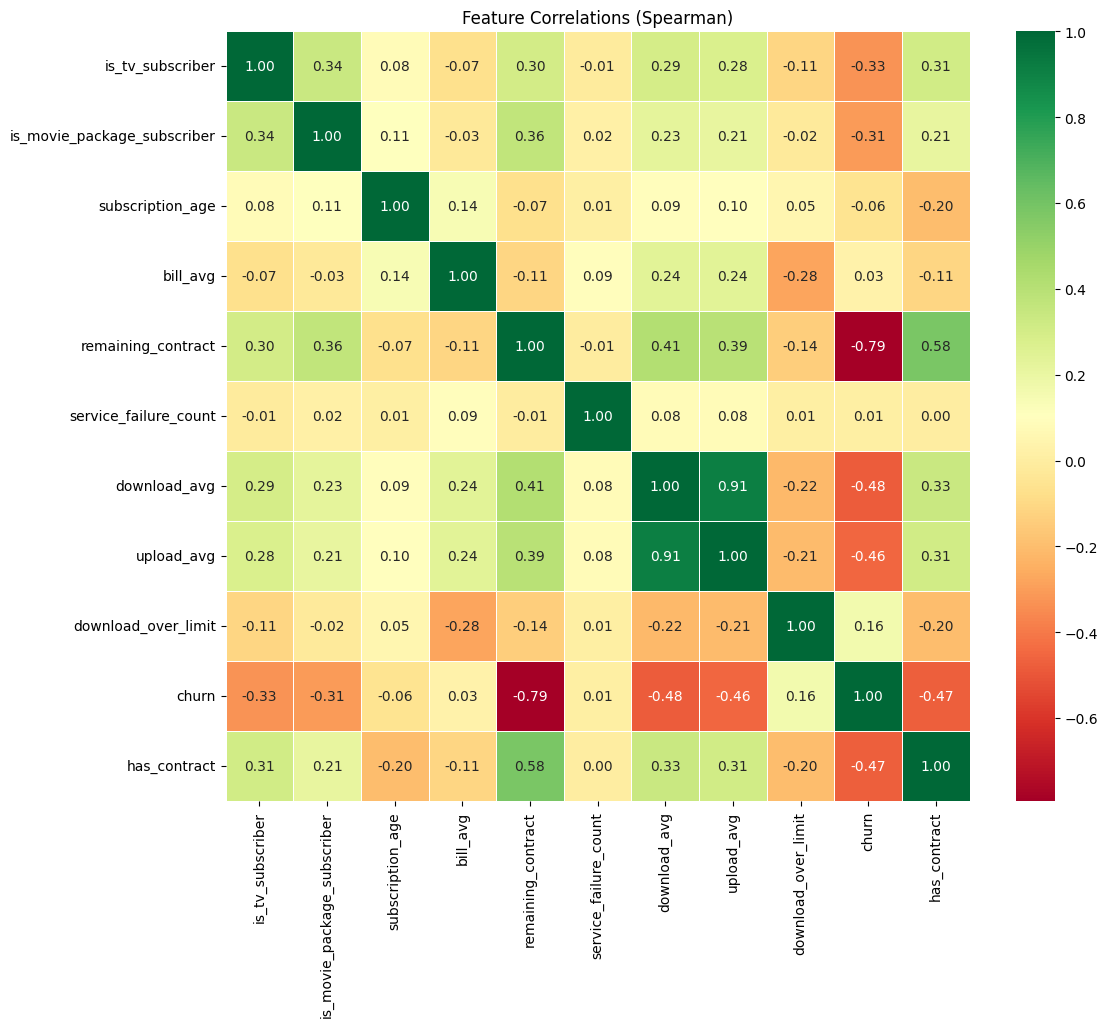

In [14]:
plt.figure(figsize=(12, 10))
corr = df.corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlations (Spearman)')
plt.show()

In [15]:
FEATURES = [
    'remaining_contract',
    'has_contract',
    'download_avg',
    'upload_avg',
    'is_tv_subscriber',
    'is_movie_package_subscriber',
    'subscription_age',
    'service_failure_count',
    'bill_avg',
    'download_over_limit',
]

TARGET = 'churn'

In [16]:
df.to_parquet('../data/processed/churn_cleaned.parquet', index=False)